# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [13]:
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

In [15]:
# Convertendo apenas as categóricas em lote para limpar o código.
col_categoricas = [
    'Idoso', 'Genero', 'Casado', 'Dependents', 'PhoneService', 
    'Servico_Internet', 'Servico_Seguranca', 'Suporte_Tecnico', 
    'StreamingTV', 'Tipo_Contrato', 'PaymentMethod', 'Churn'
]

# Convertendo todas de uma vez (as que existirem na base)
df[col_categoricas] = df[col_categoricas].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          2500 non-null   object  
 1   Genero              2488 non-null   category
 2   Idoso               2500 non-null   category
 3   Casado              2500 non-null   category
 4   Dependents          2500 non-null   category
 5   Tempo_como_Cliente  2500 non-null   int64   
 6   PhoneService        1018 non-null   category
 7   Servico_Internet    2500 non-null   category
 8   Servico_Seguranca   2500 non-null   category
 9   Suporte_Tecnico     2500 non-null   category
 10  StreamingTV         2500 non-null   category
 11  Tipo_Contrato       2500 non-null   category
 12  PaymentMethod       2500 non-null   category
 13  Pagamento_Mensal    2175 non-null   float64 
 14  Total_Pago          2500 non-null   float64 
 15  Churn               2495 non-null   ca

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [17]:
percentual_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)
percentual_nulos

PhoneService          59.28
Pagamento_Mensal      13.00
Genero                 0.48
Churn                  0.20
customerID             0.00
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Total_Pago             0.00
dtype: float64

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [ ]:
df = df.drop(columns=['PhoneService'])
# Justificativa: Mais de 50% dos dados estão faltantes, preenchimento geraria forte viés
# Baixo valor analítico comparado ao custo de imputação
df = df.dropna(subset=['Churn'])
# Justificativa: Churn é variável target, não faz sentido inferir ou imputar, poucos registros afetados (~5 linhas)

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

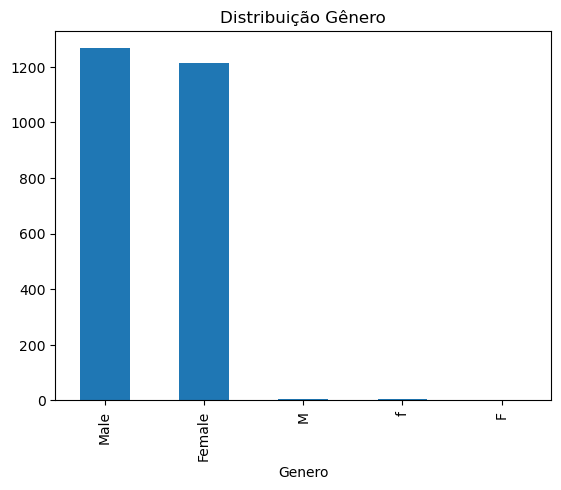

In [28]:
# Verificar distribuição antes de substituir
df['Genero'].value_counts().plot(kind='bar', title='Distribuição Gênero')
plt.show()

In [32]:
# Substituir pela moda
moda_genero = df['Genero'].mode()[0]
df['Genero'] = df['Genero'].fillna(moda_genero)

# Justificativa: poucos nulos, substituir pela moda é seguro
# e mantém a proporção original da coluna.

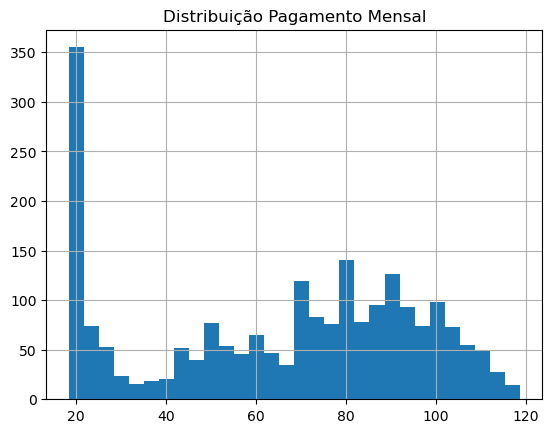

Média: 65.60756321839081
Mediana: 71.45


In [39]:
# Verificar distribuição para decidir entre média e mediana
df['Pagamento_Mensal'].hist(bins=30)
plt.title('Distribuição Pagamento Mensal') # O título vem aqui fora
plt.show()

print('Média:', df['Pagamento_Mensal'].mean())
print('Mediana:', df['Pagamento_Mensal'].median())

In [41]:
mediana = df['Pagamento_Mensal'].median()
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(mediana)

In [43]:
df.isnull().sum()

customerID            0
Genero                0
Idoso                 0
Casado                0
Dependents            0
Tempo_como_Cliente    0
Servico_Internet      0
Servico_Seguranca     0
Suporte_Tecnico       0
StreamingTV           0
Tipo_Contrato         0
PaymentMethod         0
Pagamento_Mensal      0
Total_Pago            0
Churn                 0
dtype: int64

**Justificativa**: A variável Pagamento_Mensal apresenta uma distribuição assimétrica e multimodal, com uma forte concentração de valores baixos que deslocam a média para baixo. Nesses casos, a mediana é a medida de tendência central mais indicada para a imputação, pois ela representa melhor o "centro" dos dados sem ser tão influenciada pelos valores extremos (outliers) ou pela alta frequência de planos de entrada (próximos a 20).

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [60]:
# Identificar rodas as colunas que contêm texto
colunas_para_padronizar = df.select_dtypes(include=['object', 'category']).columns

# Loop de padronização
for col in colunas_para_padronizar:
    if col != 'customerID': # O ID não deve ser alterado para 'Title' (ex: 7590-vhveg)
        # Convertemos para string, limpamos e padronizamos a capitalização
        df[col] = df[col].astype(str).str.strip().str.title()
        
    Voltar para categoria para manter a base otimizada
        df[col] = df[col].astype('category')

# Verificar se deu certo (exemplo com a coluna que tinha 'DSL' e 'dsl')
print("Verificação de valores únicos após padronização:")
print(df['Servico_Internet'].value_counts())

Verificação de valores únicos após padronização:
Servico_Internet
Fiber Optic    1124
Dsl             843
No              528
Name: count, dtype: int64


# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [66]:
# Renomear colunas para o padrão final
df = df.rename(columns={
    'customerID'        : 'id_cliente',
    'Genero'            : 'genero',
    'Idoso'             : 'idoso',
    'Casado'            : 'casado',
    'Dependents'        : 'dependentes',
    'Tempo_como_Cliente': 'tempo_cliente',
    'Servico_Internet'  : 'servico_internet',
    'Servico_Seguranca' : 'servico_seguranca',
    'Suporte_Tecnico'   : 'suporte_tecnico',
    'StreamingTV'       : 'streaming_tv',
    'Tipo_Contrato'     : 'tipo_contrato',
    'PaymentMethod'     : 'metodo_pagamento',
    'Pagamento_Mensal'  : 'pagamento_mensal',
    'Total_Pago'        : 'total_pago',
    'Churn'             : 'churn'
})

# Verificação final da estrutura
print("--- Base Finalizada com Sucesso ---")
display(df.head())
df.info()

--- Base Finalizada com Sucesso ---


,id_cliente,genero,idoso,casado,dependentes,tempo_cliente,servico_internet,servico_seguranca,suporte_tecnico,streaming_tv,tipo_contrato,metodo_pagamento,pagamento_mensal,total_pago,churn
0,7590-VHVEG,Female,0,Yes,No,1,Dsl,No,No,No,Month-To-Month,Electronic Check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Dsl,Yes,No,No,One Year,Mailed Check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Dsl,Yes,No,No,Month-To-Month,Mailed Check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,Dsl,Yes,Yes,No,One Year,Bank Transfer (Automatic),71.45,1840.75,No
4,9237-HQITU,Male,0,No,No,2,Fiber Optic,No,No,No,Month-To-Month,Electronic Check,71.45,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
Index: 2495 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id_cliente         2495 non-null   object  
 1   genero             2495 non-null   category
 2   idoso              2495 non-null   category
 3   casado             2495 non-null   category
 4   dependentes        2495 non-null   category
 5   tempo_cliente      2495 non-null   int64   
 6   servico_internet   2495 non-null   category
 7   servico_seguranca  2495 non-null   category
 8   suporte_tecnico    2495 non-null   category
 9   streaming_tv       2495 non-null   category
 10  tipo_contrato      2495 non-null   category
 11  metodo_pagamento   2495 non-null   category
 12  pagamento_mensal   2495 non-null   float64 
 13  total_pago         2495 non-null   float64 
 14  churn              2495 non-null   category
dtypes: category(11), float64(2), int64(1), object(1)
memory usag

In [64]:
# Verificação 1 — pagamento_mensal tem "Nan" escondido?
print("=== pagamento_mensal ===")
print(df['pagamento_mensal'].describe())

# Verificação 2 — idoso: ver os valores únicos
print("\n=== idoso ===")
print(df['idoso'].value_counts())

=== pagamento_mensal ===
count    2495.000000
mean       66.356894
std        28.013627
min        18.400000
25%        45.550000
50%        71.450000
75%        87.375000
max       118.650000
Name: pagamento_mensal, dtype: float64

=== idoso ===
idoso
0    2093
1     402
Name: count, dtype: int64
